# 04 — Author Publication History via OpenAlex

This notebook shows how to:
1. Retrieve all publications for an author using their OpenAlex ID
2. Paginate through results
3. Compute publication activity metrics (publications per year, active years)
4. Compute consecutive publishing years — a common seniority proxy in scientometrics
5. Visualise the publication timeline

**API docs:** https://docs.openalex.org/api-entities/works/filter-works

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
MAILTO = 'your.email@example.com'

# Use an author from notebook 03, or paste any OpenAlex author ID here
# Example: Rasheed Omobolaji Alabi — first author of the nasopharyngeal cancer paper
# We resolve this from the paper DOI
doi = '10.1038/s41598-023-35795-0'
url = f'https://api.openalex.org/works/https://doi.org/{doi}'
work = requests.get(url, params={'mailto': MAILTO}).json()

author_obj = work['authorships'][0]['author']
AUTHOR_ID = author_obj['id']  # e.g. 'https://openalex.org/A...'
AUTHOR_NAME = author_obj['display_name']
print(f'Author: {AUTHOR_NAME}')
print(f'ID    : {AUTHOR_ID}')

Author: Rasheed Omobolaji Alabi
ID    : https://openalex.org/A5083399995


## 1. Fetch all works for the author

In [3]:
def get_all_author_works(author_id: str, mailto: str = '') -> list:
    """Retrieve all works for an author using cursor pagination."""
    works = []
    cursor = '*'
    base_url = 'https://api.openalex.org/works'
    # Strip the full URL to get just the short ID (e.g. A1234567890)
    short_id = author_id.split('/')[-1]

    while True:
        params = {
            'filter': f'author.id:{short_id}',
            'per_page': 200,
            'cursor': cursor,
            'mailto': mailto,
        }
        response = requests.get(base_url, params=params)
        data = response.json()
        page = data.get('results', [])

        if not page:
            break
        works.extend(page)

        cursor = data.get('meta', {}).get('next_cursor')
        if not cursor:
            break
        time.sleep(0.1)

    print(f'Total works fetched: {len(works)}')
    return works


works = get_all_author_works(AUTHOR_ID, mailto=MAILTO)

Total works fetched: 38


## 2. Build a publication DataFrame

In [4]:
records = []
for w in works:
    records.append({
        'title': w.get('title', ''),
        'year': w.get('publication_year'),
        'cited_by_count': w.get('cited_by_count', 0),
        'type': w.get('type', ''),
        'is_oa': w.get('open_access', {}).get('is_oa', False),
        'doi': w.get('doi', ''),
    })

df_works = pd.DataFrame(records)
print(f'Publication years: {df_works["year"].min()} – {df_works["year"].max()}')
df_works.head()

Publication years: 1994 – 2025


,title,year,cited_by_count,type,is_oa,doi
0,Machine learning in oral squamous cell carcino...,2021,168,review,True,https://doi.org/10.1016/j.artmed.2021.102060
1,Machine learning explainability in nasopharyng...,2023,132,article,True,https://doi.org/10.1038/s41598-023-35795-0
2,Comparison of supervised machine learning clas...,2019,131,article,True,https://doi.org/10.1016/j.ijmedinf.2019.104068
3,Machine learning application for prediction of...,2019,106,article,True,https://doi.org/10.1007/s00428-019-02642-5
4,Comparison of nomogram with machine learning t...,2020,90,article,True,https://doi.org/10.1016/j.ijmedinf.2020.104313


## 3. Compute consecutive publishing years

A common seniority metric in scientometrics counts the number of consecutive years an author has published up to a given reference year. This is used as a proxy for career stage.

In [5]:
def consecutive_publishing_years(pub_years: list, end_year: int) -> int:
    """
    Count consecutive years with at least one publication,
    counting backwards from end_year.
    """
    years_with_pubs = set(y for y in pub_years if y is not None and y <= end_year)
    consecutive = 0
    year = end_year
    while year in years_with_pubs:
        consecutive += 1
        year -= 1
    return consecutive


def classify_seniority(consecutive_years: int) -> str:
    if consecutive_years < 3:
        return 'early'
    elif consecutive_years <= 8:
        return 'mid'
    else:
        return 'senior'


REFERENCE_YEAR = 2023
pub_years = df_works['year'].dropna().astype(int).tolist()

consec_years = consecutive_publishing_years(pub_years, REFERENCE_YEAR)
seniority = classify_seniority(consec_years)

print(f'Author           : {AUTHOR_NAME}')
print(f'Total works      : {len(df_works)}')
print(f'Consecutive years: {consec_years} (ending {REFERENCE_YEAR})')
print(f'Seniority class  : {seniority}')

Author           : Rasheed Omobolaji Alabi
Total works      : 38
Consecutive years: 5 (ending 2023)
Seniority class  : mid


## 4. Visualise publication timeline

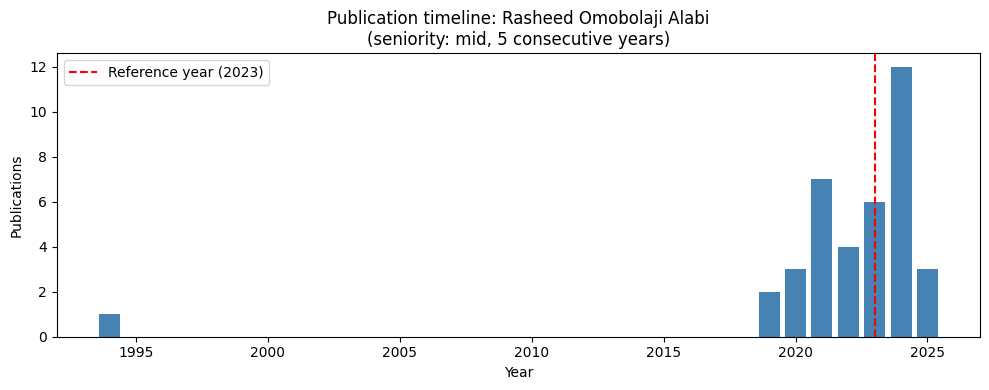

In [6]:
pubs_per_year = df_works.groupby('year').size().reset_index(name='count')
pubs_per_year = pubs_per_year.sort_values('year')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pubs_per_year['year'], pubs_per_year['count'], color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Publications')
ax.set_title(f'Publication timeline: {AUTHOR_NAME}\n(seniority: {seniority}, {consec_years} consecutive years)')
ax.axvline(REFERENCE_YEAR, color='red', linestyle='--', label=f'Reference year ({REFERENCE_YEAR})')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Top cited papers
print('Top 5 most cited papers:')
top = df_works.nlargest(5, 'cited_by_count')[['year', 'cited_by_count', 'title']]
for _, row in top.iterrows():
    print(f"  [{row['year']}] {row['cited_by_count']:4d} cit. — {str(row['title'])[:80]}")

Top 5 most cited papers:
  [2021]  168 cit. — Machine learning in oral squamous cell carcinoma: Current status, clinical conce
  [2023]  132 cit. — Machine learning explainability in nasopharyngeal cancer survival using LIME and
  [2019]  131 cit. — Comparison of supervised machine learning classification techniques in predictio
  [2019]  106 cit. — Machine learning application for prediction of locoregional recurrences in early
  [2020]   90 cit. — Comparison of nomogram with machine learning techniques for prediction of overal
